# Stage 6: Task-Specific AQG Training (Adapter-Based) WIth Dataset V3


**Version**: 3.0 (Adapter Layers - No LoRA)

Notebook ini melatih model IndoNanoT5 untuk task AQG menggunakan **Adapter Layers** (bukan LoRA).

**Configuration:**
- Adapter dimension: d=512 (reduction_factor=1.5) ⭐ OPTIMIZED for 5.6K dataset
- Trainable parameters: ~18M (7.2% dari 248M) ✅ VERIFIED
- Learning rate: 5e-5
- Batch size: 4 + gradient accumulation 2 (effective=8)
- Epochs: 10
- Memory: ~14-16GB (safe untuk T4)
- Dataset: 5,662 samples (Dataset V3 with code)


**Reference:** Based on Houlsby et al. (2019) - Parameter-Efficient Transfer Learning for NLP

## 1. Setup Environment

In [1]:
# Install dependencies
!pip install -q adapters
!pip install -q transformers datasets accelerate
!pip install -q evaluate rouge_score bert_score
print('✓ Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 107.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00
✓ Dependencies installed


In [2]:
# Cek versi semua library yang terinstall
import importlib 
import sys, torch, platform

# Add this line
import adapters

# Keep these
from adapters import AutoAdapterModel, AdapterConfig
from transformers import AutoTokenizer


libs = [
    "adapters",
    "transformers",
    "datasets",
    "accelerate",
    "evaluate",
    "torch",
    "tokenizers",
    "rouge_score",
    "bert_score",
]

print(f"Python:  {sys.version}")
print(f"OS:      {platform.system()}")
print(f"Torch:   {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}\n")

print("=== Library Versions ===")
for lib in libs:
    try:
        mod = importlib.import_module(lib.replace("-", "_"))
        version = getattr(mod, "__version__", "unknown")
        print(f"  {lib:<20} {version}")
    except ImportError:
        print(f"  {lib:<20} NOT INSTALLED")

if torch.cuda.is_available():
    print(f"\n  {'cuda version':<20} {torch.version.cuda}")
    print(f"  {'gpu name':<20} {torch.cuda.get_device_name(0)}")

Python:  3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OS:      Linux
Torch:   2.10.0+cu128
CUDA:    True

=== Library Versions ===
  adapters             1.3.0
  transformers         4.57.6
  datasets             4.0.0
  accelerate           1.13.0
  evaluate             0.4.6
  torch                2.10.0+cu128
  tokenizers           0.22.2
  rouge_score          unknown
  bert_score           0.3.12

  cuda version         12.8
  gpu name             Tesla T4


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✓ Google Drive mounted')

Mounted at /content/drive
✓ Google Drive mounted


In [4]:
# Setup paths and extract source code
import os, sys, zipfile, shutil

DRIVE_ROOT = '/content/drive/MyDrive/dataset_aqg'
sys.path.insert(0, '/content')

# Extract src if not exists
if not os.path.exists('/content/src'):
    shutil.copy(f'{DRIVE_ROOT}/src_finetuned.zip', '/content/src_finetuned.zip')
    with zipfile.ZipFile('/content/src_finetuned.zip', 'r') as z:
        z.extractall('/content/')
    print('✓ src extracted')
else:
    print('✓ src already exists')

print(f'✓ DRIVE_ROOT: {DRIVE_ROOT}')
print(f'✓ sys.path[0]: {sys.path[0]}')

✓ src extracted
✓ DRIVE_ROOT: /content/drive/MyDrive/dataset_aqg
✓ sys.path[0]: /content


In [5]:
# Verify GPU availability
import torch

if not torch.cuda.is_available():
    raise RuntimeError('GPU not available! Go to Runtime > Change runtime type > T4 GPU')

print(f'✓ GPU: {torch.cuda.get_device_name(0)}')
print(f'✓ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✓ GPU: Tesla T4
✓ Memory: 15.6 GB


## 2. Load Model with Adapter Layers

**Using**: `src.finetuned.utils.adapter_loader` (modular approach!)

In [6]:
from src.finetuned.utils.adapter_loader import load_model_with_adapter, print_adapter_info

# Load model with adapter layers
model, tokenizer = load_model_with_adapter(
    model_name='LazarusNLP/IndoNanoT5-base',
    adapter_name='mcq_generation',
    adapter_config='pfeiffer',
    reduction_factor=1.5,  # d=512 (768/1.5=512) ⭐ OPTIMIZED for 5.6K dataset
    device='cuda'
)


# Print detailed info
trainable, total = print_adapter_info(model, tokenizer)


LOADING MODEL WITH ADAPTER LAYERS
Loading base model: LazarusNLP/IndoNanoT5-base
  Using NEW adapters library (not adapter-transformers)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

⚠ AutoAdapterModel failed: The state dictionary of the model you are trying to load is corrupted. Are you s...
  Trying alternative: Load with transformers + adapters.init()


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

✓ Base model loaded with transformers + adapters.init()


✓ Adapter added: pfeiffer config, d=512.0
✓ Adapter activated for training
✓ Model moved to GPU
  GPU allocated: 1.08 GB

MODEL INFORMATION

Parameters:
  Trainable: 18,905,088 (7.09%)
  Total:     266,482,944
  Frozen:    247,577,856

Tokenizer:
  Vocab size: 32000
  Pad token:  <pad> (ID: 0)
  EOS token:  </s> (ID: 1)


## 3. Load Dataset

**Using**: `src.finetuned.data.dataset_loader` (reusable module)

In [7]:
from src.finetuned.data.dataset_loader import DatasetLoader

loader = DatasetLoader()
TASK_DIR = '/content/dataset_aqg/dataset-task-spesifc/'

# Copy dataset from Drive if needed
if not os.path.exists(TASK_DIR + 'train.jsonl'):
    drive_task = f'{DRIVE_ROOT}/dataset-task-spesifc'
    os.makedirs(TASK_DIR, exist_ok=True)
    for f in ['train.jsonl', 'validation.jsonl', 'test.jsonl']:
        shutil.copy(f'{drive_task}/{f}', f'{TASK_DIR}{f}')
    print('✓ Dataset copied from Drive')

# Load datasets
train_dataset = loader.load_dataset(TASK_DIR, split='train')
val_dataset = loader.load_dataset(TASK_DIR, split='validation')
test_dataset = loader.load_dataset(TASK_DIR, split='test')

print(f'\nDataset loaded:')
print(f'  Train: {len(train_dataset)} samples')
print(f'  Val:   {len(val_dataset)} samples')
print(f'  Test:  {len(test_dataset)} samples')

# Validate and preview
validation_results = loader.validate_dataset(train_dataset)

sample = train_dataset[0]
print('\n=== Sample Entry ===')
print(f"Input: {sample['input']}...")
output_field = 'target' if 'target' in sample else 'output'
print(f"Output: {sample[output_field]}...")
print(f'\n✓ Dataset ready (supports both v2 and v3 formats)')

✓ Dataset copied from Drive


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 4529 entries from /content/dataset_aqg/dataset-task-spesifc/train.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 566 entries from /content/dataset_aqg/dataset-task-spesifc/validation.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 567 entries from /content/dataset_aqg/dataset-task-spesifc/test.jsonl

Dataset loaded:
  Train: 4529 samples
  Val:   566 samples
  Test:  567 samples
✓ Using output field: 'output'

=== Dataset Validation Summary ===
Total Entries: 4529
Duplicate Count: 0
Avg Input Length: 195.65 chars
Avg Target Length: 239.35 chars
Has Metadata: True
✓ No duplicates found

=== Sample Entry ===
Input: buat_soal_pilihan_ganda: Perhatikan kode berikut:
```python
var_mat = [[10, 20],
           [30, 40],
           [50, 60]]
print(var_mat[0][1] + var_mat[2][1])
```
Kode ini menjumlahkan elemen kolom kedua dari baris pertama dan baris terakhir....
Output: question: Perhatikan kode berikut:
```python
var_mat = [[10, 20],
           [30, 40],
           [50, 60]]
print(var_mat[0][1] + var_mat[2][1])
```
Apa output dari kode tersebut?
answer: 80
distractors: 70 | 90 | 60...

✓ Dataset ready (supports both v2 and v3 formats)


## 4. Baseline Evaluation

**Using**: `src.finetuned.evaluation` modules

In [8]:
from src.finetuned.evaluation.metrics_calculator import MetricsCalculator
from src.finetuned.evaluation.model_evaluator import ModelEvaluator

metrics_calc = MetricsCalculator()
evaluator = ModelEvaluator(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc
)

print('Computing baseline metrics (10 samples)...')
baseline_metrics = evaluator.evaluate_on_test_set(
    test_dataset=val_dataset,
    num_beams=4,
    include_bertscore=False,
    max_samples=10
)

print(f"\nBaseline Metrics:")
print(f"  BLEU-4:  {baseline_metrics.get('bleu_4', 0):.4f}")
print(f"  ROUGE-L: {baseline_metrics.get('rouge_l', 0):.4f}")

Computing baseline metrics (10 samples)...

EVALUATING ON TEST SET

Evaluating 10 samples...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)


  Processed 10/10 samples...
✓ Generated 10 predictions
Computing metrics for 10 samples...
  Computing BLEU...


  Computing ROUGE...


  Computing Diversity...
✓ All metrics computed

Test Set Evaluation Results

BLEU Scores:
  BLEU:     0.0063
  BLEU-1:   0.0623
  BLEU-2:   0.0057
  BLEU-3:   0.0029
  BLEU-4:   0.0015

ROUGE Scores:
  ROUGE-1:  0.0939
  ROUGE-2:  0.0133
  ROUGE-L:  0.0919

Diversity:
  Distinct-1: 0.6102
  Distinct-2: 0.8523


Baseline Metrics:
  BLEU-4:  0.0015
  ROUGE-L: 0.0919


## 5. Configure Training

**Using**: `src.finetuned.training.adapter_trainer` (modular approach!)

In [9]:
from src.finetuned.training.adapter_trainer import AdapterTrainer

CHECKPOINT_DIR = '/content/drive/MyDrive/dataset_aqg/checkpoints/12-indonanoot5-report'
# Initialize trainer
trainer = AdapterTrainer(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc,
    output_dir=CHECKPOINT_DIR,
    max_length=512
)

# Setup training configuration
training_args = trainer.setup_training(
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01
)


print('\n✓ Trainer configured')
print(f'  Checkpoints will be saved to: {CHECKPOINT_DIR}')


TRAINING CONFIGURATION
Epochs: 10
Batch size: 4
Effective batch size: 8
Learning rate: 5e-05
Warmup steps: 100
FP16: True
Gradient checkpointing: True

✓ Trainer configured
  Checkpoints will be saved to: /content/drive/MyDrive/dataset_aqg/checkpoints/12-indonanoot5-report


## 6. Start Training

**⚠️ This will take 6-8 hours on T4 GPU**

In [10]:
import time
import os
from pathlib import Path

start_time = time.time()

# Ensure checkpoint directory exists
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

# Check for existing checkpoints
checkpoints = []
if os.path.exists(CHECKPOINT_DIR):
    checkpoints = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith('checkpoint-')]

# Decide whether to resume
if checkpoints:
    print(f"📂 Found {len(checkpoints)} checkpoint(s): {sorted(checkpoints)}")
    print(f"🔄 Resuming from last checkpoint")
    resume = True
else:
    print("🆕 No checkpoints found - starting fresh training")
    resume = False

# Train
results = trainer.train(
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    training_args=training_args,
    early_stopping_patience=2,
    resume_from_checkpoint=resume  # ✅ Only True if checkpoints exist
)

elapsed = (time.time() - start_time) / 3600
print(f'\n✓ Training completed in {elapsed:.2f} hours')
print(f'  Final training loss: {results["training_loss"]:.4f}')


Parameter 'function'=<function AdapterTrainer.preprocess_dataset.<locals>.preprocess_function at 0x791f6d2d2520> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


📂 Found 2 checkpoint(s): ['checkpoint-5103', 'checkpoint-5670']
🔄 Resuming from last checkpoint

PREPROCESSING DATASETS


Tokenizing:   0%|          | 0/4529 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/566 [00:00<?, ? examples/s]

✓ Datasets tokenized
✓ Data collator configured
✓ Trainer initialized (with transformers 4.46+ compatibility fix)
📂 Found 2 checkpoint(s): ['checkpoint-5103', 'checkpoint-5670']
🔄 Resuming from: checkpoint-5670

STARTING TRAINING
Training with Adapter Layers (d=64, ~3.6% trainable params)
Expected time: 6-8 hours on T4 GPU
Total epochs: 10



There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Epoch,Training Loss,Validation Loss



✓ Training completed in 0.01 hours
  Final training loss: 0.0000


## 7. Save Adapter & Visualize


SAVING ADAPTER WEIGHTS
✓ Adapter weights saved to: /content/drive/MyDrive/dataset_aqg/checkpoints/12-indonanoot5-report/adapter_mcq_generation
✓ Tokenizer saved
✓ Config saved
✓ Plot saved to /content/drive/MyDrive/dataset_aqg/checkpoints/12-indonanoot5-report/training_curves.png


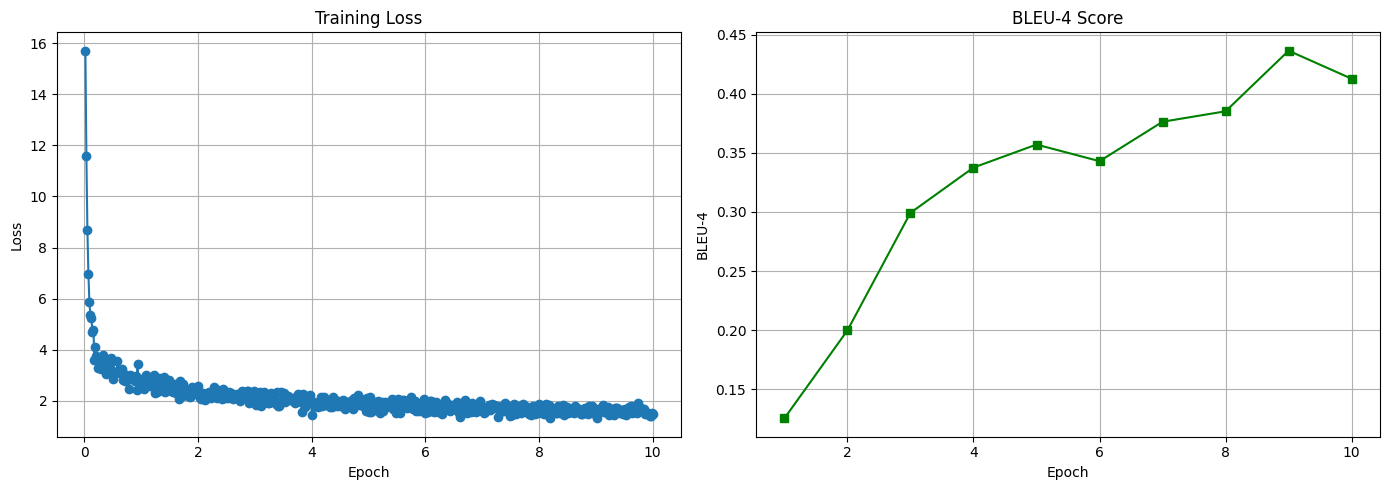

In [11]:
# Save adapter weights
adapter_save_path = trainer.save_adapter(
    adapter_name='mcq_generation',
    save_config={
        "model_name": "LazarusNLP/IndoNanoT5-base",
        "adapter_config": "pfeiffer",
        "reduction_factor": 1.5,  # ⭐ d=512
        "adapter_dimension": 512,  # ⭐ Explicit dimension
        "trainable_params": trainable,
        "total_params": total,
        "num_train_epochs": 10,
        "learning_rate": 5e-5,
        "training_time_hours": elapsed
    }
)


# Plot training curves
trainer.plot_training_curves(
    save_path=f'{CHECKPOINT_DIR}/training_curves.png'
)

## 8. Final Evaluation

In [12]:
# Re-initialize evaluator with trained model
evaluator_final = ModelEvaluator(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc
)

print('Running comprehensive evaluation on test set...')
final_metrics = evaluator_final.evaluate_on_test_set(
    test_dataset=test_dataset,
    num_beams=4,
    include_bertscore=True,
    max_samples=None
)

print('\n=== Evaluation Results ===')
for key, value in final_metrics.items():
    print(f'{key}: {value:.4f}')

Running comprehensive evaluation on test set...

EVALUATING ON TEST SET

Evaluating 567 samples...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)


  Processed 10/567 samples...
  Processed 20/567 samples...
  Processed 30/567 samples...
  Processed 40/567 samples...
  Processed 50/567 samples...
  Processed 60/567 samples...
  Processed 70/567 samples...
  Processed 80/567 samples...
  Processed 90/567 samples...
  Processed 100/567 samples...
  Processed 110/567 samples...
  Processed 120/567 samples...
  Processed 130/567 samples...
  Processed 140/567 samples...
  Processed 150/567 samples...
  Processed 160/567 samples...
  Processed 170/567 samples...
  Processed 180/567 samples...
  Processed 190/567 samples...
  Processed 200/567 samples...
  Processed 210/567 samples...
  Processed 220/567 samples...
  Processed 230/567 samples...
  Processed 240/567 samples...
  Processed 250/567 samples...
  Processed 260/567 samples...
  Processed 270/567 samples...
  Processed 280/567 samples...
  Processed 290/567 samples...
  Processed 300/567 samples...
  Processed 310/567 samples...
  Processed 320/567 samples...
  Processed 330/5

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

  Computing Diversity...
✓ All metrics computed

Test Set Evaluation Results

BLEU Scores:
  BLEU:     0.3052
  BLEU-1:   0.6159
  BLEU-2:   0.4164
  BLEU-3:   0.3026
  BLEU-4:   0.2476

ROUGE Scores:
  ROUGE-1:  0.5405
  ROUGE-2:  0.3547
  ROUGE-L:  0.4909

BERTScore:
  Precision: 0.8060
  Recall:    0.7920
  F1:        0.7984

Diversity:
  Distinct-1: 0.1422
  Distinct-2: 0.4342


=== Evaluation Results ===
bleu: 0.3052
bleu_1: 0.6159
bleu_2: 0.4164
bleu_3: 0.3026
bleu_4: 0.2476
brevity_penalty: 0.8198
length_ratio: 0.8342
rouge_1: 0.5405
rouge_2: 0.3547
rouge_l: 0.4909
rouge_1_fmeasure: 0.5405
rouge_2_fmeasure: 0.3547
rouge_l_fmeasure: 0.4909
bertscore_precision: 0.8060
bertscore_recall: 0.7920
bertscore_f1: 0.7984
distinct_1: 0.1422
distinct_2: 0.4342


## 9. Generate Sample Outputs

In [13]:
EVAL_DIR = '/content/drive/MyDrive/dataset_aqg/evaluation_results/12-indonanoot5-report'

# ✅ generate_samples() already prints full output with nice formatting
# No need to print again here
samples = evaluator_final.generate_samples(
    test_dataset=test_dataset,
    num_samples=20,
    num_beams=4,
    save_path=f'{EVAL_DIR}/sample_outputs.json'
)

print(f'\n✓ {len(samples)} samples generated and saved')
print(f'✓ Full output displayed above with BLEU scores')



Generating 20 sample outputs...

Sample 1/20

📥 INPUT:
buat_soal_pilihan_ganda: Matriks dapat digunakan untuk merepresentasikan berbagai data dalam kehidupan nyata, seperti gambar digital (pixel), tabel data, graf (adjacency matrix), atau sistem persamaan linear.

✅ REFERENCE:
question: Apa saja contoh penggunaan matriks dalam kehidupan nyata?
answer: Gambar digital, tabel data, graf, sistem persamaan linear
distractors: Hanya untuk perhitungan matematika | Hanya untuk menyimpan angka | Hanya untuk grafik komputer

🤖 PREDICTION:
question: bagaimana matriks dapat merepresentasikan berbagai data dalam kehidupan nyata? answer: gambar digital (pixel), tabel data, graf (adjacency matrix) atau sistem persamaan linear distractors: hanya angka | hanya gambar | tidak ada fungsi

📊 BLEU Score: 0.3005

Sample 2/20

📥 INPUT:
buat_soal_pilihan_ganda: Dalam penerapan unit test, test case dapat menggunakan assertion untuk memverifikasi bahwa string tidak mengandung substring. Ini berguna untuk memas

## 10. Final Summary

In [14]:
import json
from pathlib import Path

# Compare with baseline
comparison = evaluator_final.compare_with_baseline(
    finetuned_metrics=final_metrics,
    baseline_metrics=baseline_metrics
)

# Save evaluation report
Path(EVAL_DIR).mkdir(parents=True, exist_ok=True)

report = {
    'version': '3.1 (Adapter d=512 - Dataset V3)',  # ⭐ Updated version
    'baseline_metrics': baseline_metrics,
    'final_metrics': final_metrics,
    'comparison': comparison,
    'training_time_hours': elapsed,
    'adapter_path': adapter_save_path,
    'config': {
        'adapter_config': 'pfeiffer',
        'reduction_factor': 1.5,  # ⭐ d=512
        'adapter_dimension': 512,  # ⭐ Explicit
        'learning_rate': 5e-5,
        'batch_size': 8,  # Effective batch size
        'epochs': 12
    }
}


with open(f'{EVAL_DIR}/evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

# Print summary
print('\n' + '='*60)
print('ADAPTER-BASED AQG TRAINING SUMMARY')
print('='*60)
# Section 10: Final Summary
print(f'Method: Adapter Layers (d=512) ⭐ Dataset V3 (5,662 samples)')
print(f'Training Time: {elapsed:.2f} hours')
print(f'Trainable: {100*trainable/total:.2f}%')
print(f'\nMetrics Comparison:')
print(f"  BLEU-4:  {baseline_metrics.get('bleu_4',0):.4f} → {final_metrics.get('bleu_4',0):.4f}")
print(f"  ROUGE-L: {baseline_metrics.get('rouge_l',0):.4f} → {final_metrics.get('rouge_l',0):.4f}")

bleu_improvement = comparison.get('bleu_4_improvement_pct', 0)
print(f'\nBLEU-4 Improvement: {bleu_improvement:+.1f}%')

if final_metrics.get('bleu_4', 0) >= 0.20:
    print('\n✓ SUCCESS: BLEU-4 target achieved (>= 0.20)')
else:
    print(f"\n⚠ BLEU-4 = {final_metrics.get('bleu_4',0):.4f} (target: >= 0.20)")
    print('  Consider: more epochs or adjust hyperparameters')

print('\n✓ Fine-tuning pipeline complete!')
print(f'  Adapter: {adapter_save_path}')
print(f'  Report: {EVAL_DIR}/evaluation_report.json')
print(f'  Samples: {EVAL_DIR}/sample_outputs.json')

print('\n' + '='*60)
print('HOW TO LOAD TRAINED ADAPTER')
print('='*60)
print('from adapters import AutoAdapterModel')
print('from transformers import AutoTokenizer')
print('')
print('model = AutoAdapterModel.from_pretrained("LazarusNLP/IndoNanoT5-base")')
print('tokenizer = AutoTokenizer.from_pretrained("LazarusNLP/IndoNanoT5-base")')
print(f'model.load_adapter("{adapter_save_path}")')
print('model.set_active_adapters("mcq_generation")')
print('')
print('# Generate')
print('inputs = tokenizer("generate_mcq: [CONTEXT]", return_tensors="pt")')
print('outputs = model.generate(**inputs, max_length=512, num_beams=4)')
print('print(tokenizer.decode(outputs[0], skip_special_tokens=True))')


COMPARING WITH BASELINE

Metric                        Baseline   Fine-tuned  Improvement
-----------------------------------------------------------------
bleu                            0.0063       0.3052     4768.82%
bleu_1                          0.0623       0.6159      888.18%
bleu_2                          0.0057       0.4164     7145.99%
bleu_3                          0.0029       0.3026    10279.63%
bleu_4                          0.0015       0.2476    16639.13%
brevity_penalty                 1.0000       0.8198      -18.02%
length_ratio                    1.4617       0.8342      -42.93%
rouge_1                         0.0939       0.5405      475.80%
rouge_2                         0.0133       0.3547     2569.00%
rouge_l                         0.0919       0.4909      434.43%
rouge_1_fmeasure                0.0939       0.5405      475.80%
rouge_2_fmeasure                0.0133       0.3547     2569.00%
rouge_l_fmeasure                0.0919       0.4909      434.43